In [6]:
import pandas as pd

file_path = "C:/Users/Aman Mishra/Desktop/freightcost/Supply chain logisitcs problem.xlsx"

orders = pd.read_excel("C:/Users/Aman Mishra/Desktop/freightcost/Supply chain logisitcs problem.xlsx", sheet_name="OrderList")
freight_rates = pd.read_excel("C:/Users/Aman Mishra/Desktop/freightcost/Supply chain logisitcs problem.xlsx", sheet_name="FreightRates")
wh_costs = pd.read_excel("C:/Users/Aman Mishra/Desktop/freightcost/Supply chain logisitcs problem.xlsx", sheet_name="WhCosts")
wh_capacities = pd.read_excel("C:/Users/Aman Mishra/Desktop/freightcost/Supply chain logisitcs problem.xlsx", sheet_name="WhCapacities")
products_per_plant = pd.read_excel("C:/Users/Aman Mishra/Desktop/freightcost/Supply chain logisitcs problem.xlsx", sheet_name="ProductsPerPlant")
vmi_customers = pd.read_excel("C:/Users/Aman Mishra/Desktop/freightcost/Supply chain logisitcs problem.xlsx", sheet_name="VmiCustomers")
plant_ports = pd.read_excel("C:/Users/Aman Mishra/Desktop/freightcost/Supply chain logisitcs problem.xlsx", sheet_name="PlantPorts")

In [7]:
print("Orders:", orders.shape)
print("Freight Rates:", freight_rates.shape)
print("Warehouse Costs:", wh_costs.shape)
print("Warehouse Capacities:", wh_capacities.shape)
print("Products per Plant:", products_per_plant.shape)
print("VMI Customers:", vmi_customers.shape)
print("Plant Ports:", plant_ports.shape)

Orders: (9215, 14)
Freight Rates: (1540, 11)
Warehouse Costs: (19, 2)
Warehouse Capacities: (19, 2)
Products per Plant: (2036, 2)
VMI Customers: (14, 2)
Plant Ports: (22, 2)


In [8]:
orders.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Order ID,9215.0,NaN,NaN,NaN,1447273698.881769,1447125805.7,1447196681.2,1447275684.7,1447346498.7,1447425230.7,83816.29279
Order Date,9215,NaN,NaN,NaN,2013-05-26 00:00:00,2013-05-26 00:00:00,2013-05-26 00:00:00,2013-05-26 00:00:00,2013-05-26 00:00:00,2013-05-26 00:00:00,NaN
Origin Port,9215,3,PORT04,9041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carrier,9215,3,V444_0,6264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TPT,9215.0,NaN,NaN,NaN,1.717743,0.0,1.0,2.0,2.0,4.0,0.6305
Service Level,9215,3,DTP,6218,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship ahead day count,9215.0,NaN,NaN,NaN,1.852306,0.0,0.0,3.0,3.0,6.0,1.922302
Ship Late Day count,9215.0,NaN,NaN,NaN,0.039935,0.0,0.0,0.0,0.0,6.0,0.319625
Customer,9215,46,V55555555555555_8,976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product ID,9215.0,NaN,NaN,NaN,1680536.058709,1613321.0,1669702.0,1683636.0,1689554.0,1702654.0,15265.927778


In [9]:
orders.isnull().sum()

Order ID                0
Order Date              0
Origin Port             0
Carrier                 0
TPT                     0
Service Level           0
Ship ahead day count    0
Ship Late Day count     0
Customer                0
Product ID              0
Plant Code              0
Destination Port        0
Unit quantity           0
Weight                  0
dtype: int64

In [10]:
freight_rates.isnull().sum()

Carrier         0
orig_port_cd    0
dest_port_cd    0
minm_wgh_qty    0
max_wgh_qty     0
svc_cd          0
minimum cost    0
rate            0
mode_dsc        0
tpt_day_cnt     0
Carrier type    0
dtype: int64

In [11]:
orders["Order ID"].duplicated().sum()

np.int64(0)

In [12]:
print("Orders:", orders["Order ID"].nunique())
print("Carriers:", orders["Carrier"].nunique())
print("Origin Ports:", orders["Origin Port"].nunique())
print("Destination Ports:", orders["Destination Port"].nunique())
print("Customers:", orders["Customer"].nunique())
print("Products:", orders["Product ID"].nunique())
print("Plants:", orders["Plant Code"].nunique())

Orders: 9215
Carriers: 3
Origin Ports: 3
Destination Ports: 1
Customers: 46
Products: 772
Plants: 7


In [13]:
print("Carriers:")
print(orders["Carrier"].value_counts())

Carriers:
Carrier
V444_0    6264
V444_1    2097
V44_3      854
Name: count, dtype: int64


In [14]:
print("\nOrigin Ports:")
print(orders["Origin Port"].value_counts())


Origin Ports:
Origin Port
PORT04    9041
PORT09     173
PORT05       1
Name: count, dtype: int64


In [15]:
print("\nTransport Planning Time:")
print(orders["TPT"].value_counts().sort_index())


Transport Planning Time:
TPT
0     411
1    2123
2    6480
3      58
4     143
Name: count, dtype: int64


In [16]:
print("\nPlants:")
print(orders["Plant Code"].value_counts())


Plants:
Plant Code
PLANT03    8541
PLANT12     300
PLANT16     173
PLANT08     102
PLANT13      86
PLANT09      12
PLANT04       1
Name: count, dtype: int64


In [17]:
orders["Weight"].describe()

count    9215.000000
mean       19.871688
std        66.569064
min         0.000000
25%         1.407430
50%         4.440000
75%        13.325673
max      2338.405126
Name: Weight, dtype: float64

<Axes: >

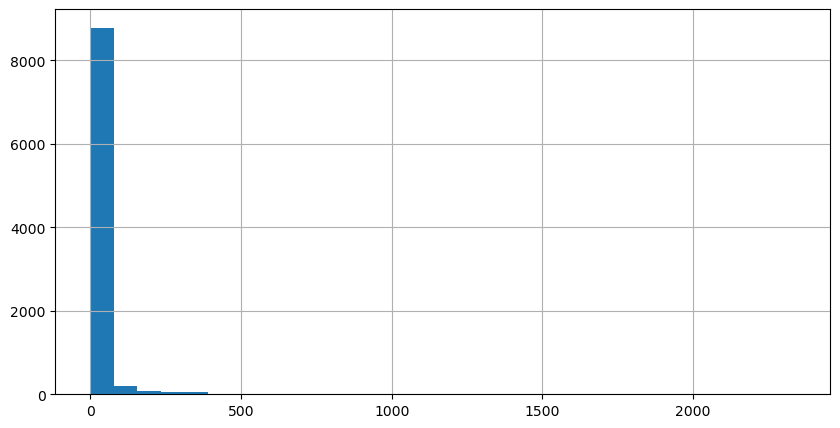

In [18]:
orders["Weight"].hist(bins=30, figsize=(10, 5))

In [19]:
orders[["Unit quantity", "Weight"]].corr()

,Unit quantity,Weight
Unit quantity,1.00000,0.34452
Weight,0.34452,1.00000


In [22]:
freight_rates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1540 entries, 0 to 1539
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Carrier       1540 non-null   object 
 1   orig_port_cd  1540 non-null   object 
 2   dest_port_cd  1540 non-null   object 
 3   minm_wgh_qty  1540 non-null   float64
 4   max_wgh_qty   1540 non-null   float64
 5   svc_cd        1540 non-null   object 
 6   minimum cost  1540 non-null   float64
 7   rate          1540 non-null   float64
 8   mode_dsc      1540 non-null   object 
 9   tpt_day_cnt   1540 non-null   int64  
 10  Carrier type  1540 non-null   object 
dtypes: float64(4), int64(1), object(6)
memory usage: 132.5+ KB


In [23]:
freight_rates.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Carrier,1540,9,V444_4,906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
orig_port_cd,1540,10,PORT06,479,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dest_port_cd,1540,1,PORT09,1540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
minm_wgh_qty,1540.0,NaN,NaN,NaN,155.886637,475.952049,0.0,15.01,41.01,67.229614,10000.0
max_wgh_qty,1540.0,NaN,NaN,NaN,4636.143633,20251.309727,0.453592,21.5,47.5,99.99,99999.99
svc_cd,1540,2,DTD,1322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
minimum cost,1540.0,NaN,NaN,NaN,12.329033,22.946192,1.202,3.6568,7.417,11.4945,425.0272
rate,1540.0,NaN,NaN,NaN,2.892656,4.603877,0.0332,0.4704,1.6612,3.9322,128.0272
mode_dsc,1540,2,AIR,1511,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tpt_day_cnt,1540.0,NaN,NaN,NaN,2.186364,2.000895,0.0,1.0,2.0,2.0,14.0


In [24]:
print("Carriers in rate table:")
print(freight_rates["Carrier"].unique())

print("\nOrigin ports:")
print(freight_rates["orig_port_cd"].unique())

print("\nDestination ports:")
print(freight_rates["dest_port_cd"].unique())

print("\nService codes:")
print(freight_rates["svc_cd"].unique())

Carriers in rate table:
['V444_6' 'V444_8' 'V444_9' 'V444_2' 'V444_1' 'V444_0' 'V444_5' 'V444_4'
 'V444_7']

Origin ports:
['PORT08' 'PORT10' 'PORT09' 'PORT11' 'PORT04' 'PORT02' 'PORT03' 'PORT07'
 'PORT05' 'PORT06']

Destination ports:
['PORT09']

Service codes:
['DTD' 'DTP']


In [25]:
orders["Service Level"].value_counts()

Service Level
DTP    6218
DTD    2143
CRF     854
Name: count, dtype: int64

In [26]:
freight_rates["svc_cd"].value_counts()

svc_cd
DTD    1322
DTP     218
Name: count, dtype: int64

In [32]:
matched_rates = orders_rate[
    orders_rate["Weight"].between(
        orders_rate["minm_wgh_qty"],
        orders_rate["max_wgh_qty"],
        inclusive="both"
    )
].copy()
print("Before weight matching:", len(orders_rate))
print("After weight matching:", len(matched_rates))

Before weight matching: 147068
After weight matching: 15402


In [66]:
print("Order TPT values:")
print(sorted(orders["TPT"].unique()))

print("\nFreight rate TPT values:")
print(sorted(freight_rates["tpt_day_cnt"].unique()))

print("\nData types:")
print("orders TPT:", orders["TPT"].dtype)
print("rate TPT:", freight_rates["tpt_day_cnt"].dtype)

Order TPT values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Freight rate TPT values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(14)]

Data types:
orders TPT: int64
rate TPT: int64


In [67]:
orders_with_price_variation = pricing_variation[
    (pricing_variation["minimum cost"] > 1) |
    (pricing_variation["rate"] > 1) |
    (pricing_variation["mode_dsc"] > 1)
]

print("Orders with actual pricing variation:",
      len(orders_with_price_variation))

Orders with actual pricing variation: 727


In [69]:
print(
    unmatched_orders[
        unmatched_orders["Service Level"] == "DTD"
    ]["Carrier"].value_counts()
)

Carrier
V444_1    1370
Name: count, dtype: int64


In [71]:
price_cols = [
    "minimum cost",
    "rate",
    "mode_dsc"
]

pricing_variation = (
    matched_rates
    .groupby("Order ID")[price_cols]
    .nunique()
)

print(pricing_variation.value_counts())

minimum cost  rate  mode_dsc
1             1     1           6264
2             2     1            727
Name: count, dtype: int64


In [72]:
orders_with_price_variation = pricing_variation[
    (pricing_variation["minimum cost"] > 1) |
    (pricing_variation["rate"] > 1) |
    (pricing_variation["mode_dsc"] > 1)
]

print("Orders with actual pricing variation:",
      len(orders_with_price_variation))

Orders with actual pricing variation: 727


In [73]:
print(
    unmatched_orders[
        unmatched_orders["Service Level"] == "DTD"
    ]["Carrier"].value_counts()
)

Carrier
V444_1    1370
Name: count, dtype: int64


In [76]:
unmatched_dtd = unmatched_orders[
    unmatched_orders["Service Level"] == "DTD"
].copy()

print(
    unmatched_dtd[
        ["Carrier", "Origin Port", "Destination Port", "Weight"]
    ].head(20)
)

print("\nRoute combinations:")
print(
    unmatched_dtd[
        ["Origin Port", "Destination Port"]
    ].value_counts()
)

     Carrier Origin Port Destination Port     Weight
7118  V444_1      PORT04           PORT09  31.927536
7119  V444_1      PORT04           PORT09  11.800000
7121  V444_1      PORT04           PORT09  27.500000
7122  V444_1      PORT04           PORT09  29.000000
7123  V444_1      PORT04           PORT09  22.000000
7124  V444_1      PORT04           PORT09  29.000000
7125  V444_1      PORT04           PORT09  45.600000
7126  V444_1      PORT04           PORT09  17.100000
7127  V444_1      PORT04           PORT09  26.500000
7128  V444_1      PORT04           PORT09  17.314886
7129  V444_1      PORT04           PORT09  11.876591
7130  V444_1      PORT04           PORT09  22.753182
7131  V444_1      PORT04           PORT09  21.753182
7132  V444_1      PORT04           PORT09  64.259545
7133  V444_1      PORT04           PORT09  10.876591
7134  V444_1      PORT04           PORT09  34.629773
7135  V444_1      PORT04           PORT09  10.876591
7136  V444_1      PORT04           PORT09  11.

In [81]:
example_order = orders_with_price_variation.index[0]

print(
    matched_rates[
        matched_rates["Order ID"] == example_order
    ][
        [
            "Order ID",
            "Carrier",
            "Origin Port",
            "Destination Port",
            "Service Level",
            "Weight",
            "minimum cost",
            "rate",
            "mode_dsc",
            "tpt_day_cnt"
        ]
    ]
)

            Order ID Carrier Origin Port Destination Port Service Level  \
119510  1.447139e+09  V444_1      PORT04           PORT09           DTD   
119520  1.447139e+09  V444_1      PORT04           PORT09           DTD   
119530  1.447139e+09  V444_1      PORT04           PORT09           DTD   
119540  1.447139e+09  V444_1      PORT04           PORT09           DTD   

          Weight  minimum cost    rate mode_dsc  tpt_day_cnt  
119510  1.225287        1.3192  0.3192   AIR             2.0  
119520  1.225287        1.4824  0.4824   AIR             2.0  
119530  1.225287        1.3192  0.3192   AIR             1.0  
119540  1.225287        1.4824  0.4824   AIR             1.0  


In [84]:
order_option_analysis = (
    matched_rates
    .groupby("Order ID")
    .agg(
        price_options=("rate", "nunique"),
        tpt_options=("tpt_day_cnt", "nunique"),
        mode_options=("mode_dsc", "nunique")
    )
)

print(order_option_analysis.value_counts())

price_options  tpt_options  mode_options
1              2            1               6230
2              2            1                727
1              1            1                 34
Name: count, dtype: int64


In [85]:
variation_summary = (
    order_option_analysis.loc[
        orders_with_price_variation.index
    ]
)

print(variation_summary.value_counts())

price_options  tpt_options  mode_options
2              2            1               727
Name: count, dtype: int64


In [87]:
example_order = orders_with_price_variation.index[0]

print(
    matched_rates[
        matched_rates["Order ID"] == example_order
    ][
        [
            "Order ID",
            "Carrier",
            "Origin Port",
            "Destination Port",
            "Service Level",
            "Weight",
            "minimum cost",
            "rate",
            "mode_dsc",
            "tpt_day_cnt"
        ]
    ]
)

            Order ID Carrier Origin Port Destination Port Service Level  \
119510  1.447139e+09  V444_1      PORT04           PORT09           DTD   
119520  1.447139e+09  V444_1      PORT04           PORT09           DTD   
119530  1.447139e+09  V444_1      PORT04           PORT09           DTD   
119540  1.447139e+09  V444_1      PORT04           PORT09           DTD   

          Weight  minimum cost    rate mode_dsc  tpt_day_cnt  
119510  1.225287        1.3192  0.3192   AIR             2.0  
119520  1.225287        1.4824  0.4824   AIR             2.0  
119530  1.225287        1.3192  0.3192   AIR             1.0  
119540  1.225287        1.4824  0.4824   AIR             1.0  


In [89]:
print(matched_rates.columns.tolist())

['Order ID', 'Order Date', 'Origin Port', 'Carrier', 'TPT', 'Service Level', 'Ship ahead day count', 'Ship Late Day count', 'Customer', 'Product ID', 'Plant Code', 'Destination Port', 'Unit quantity', 'Weight', 'orig_port_cd', 'dest_port_cd', 'minm_wgh_qty', 'max_wgh_qty', 'svc_cd', 'minimum cost', 'rate', 'mode_dsc', 'tpt_day_cnt', 'Carrier type', 'expected_freight_cost']


In [90]:
print(
    matched_rates[
        matched_rates["Order ID"] == example_order
    ].columns.tolist()
)

['Order ID', 'Order Date', 'Origin Port', 'Carrier', 'TPT', 'Service Level', 'Ship ahead day count', 'Ship Late Day count', 'Customer', 'Product ID', 'Plant Code', 'Destination Port', 'Unit quantity', 'Weight', 'orig_port_cd', 'dest_port_cd', 'minm_wgh_qty', 'max_wgh_qty', 'svc_cd', 'minimum cost', 'rate', 'mode_dsc', 'tpt_day_cnt', 'Carrier type', 'expected_freight_cost']


In [92]:
example_rows = matched_rates.loc[
    matched_rates["Order ID"] == example_order
]

print(example_rows)

            Order ID Order Date Origin Port Carrier  TPT Service Level  \
119510  1.447139e+09 2013-05-26      PORT04  V444_1    1           DTD   
119520  1.447139e+09 2013-05-26      PORT04  V444_1    1           DTD   
119530  1.447139e+09 2013-05-26      PORT04  V444_1    1           DTD   
119540  1.447139e+09 2013-05-26      PORT04  V444_1    1           DTD   

        Ship ahead day count  Ship Late Day count           Customer  \
119510                     5                    0  V55555555555555_8   
119520                     5                    0  V55555555555555_8   
119530                     5                    0  V55555555555555_8   
119540                     5                    0  V55555555555555_8   

        Product ID  ... dest_port_cd minm_wgh_qty  max_wgh_qty  svc_cd  \
119510     1689543  ...       PORT09         1.01          1.5     DTD   
119520     1689543  ...       PORT09         1.01          1.5     DTD   
119530     1689543  ...       PORT09         1

In [93]:
cols = [
    "Order ID",
    "Carrier",
    "Origin Port",
    "Destination Port",
    "Service Level",
    "Weight",
    "minm_wgh_qty",
    "maxm_wgh_qty",
    "minimum cost",
    "rate",
    "mode_dsc",
    "tpt_day_cnt",
    "Carrier type"
]

print(
    example_rows.filter(items=cols).to_string(index=False)
)

    Order ID Carrier Origin Port Destination Port Service Level   Weight  minm_wgh_qty  minimum cost   rate mode_dsc  tpt_day_cnt Carrier type
1447139280.7  V444_1      PORT04           PORT09           DTD 1.225287          1.01        1.3192 0.3192   AIR             2.0 V888888883_1
1447139280.7  V444_1      PORT04           PORT09           DTD 1.225287          1.01        1.4824 0.4824   AIR             2.0 V888888883_1
1447139280.7  V444_1      PORT04           PORT09           DTD 1.225287          1.01        1.3192 0.3192   AIR             1.0 V888888883_1
1447139280.7  V444_1      PORT04           PORT09           DTD 1.225287          1.01        1.4824 0.4824   AIR             1.0 V888888883_1


In [94]:
print(
    orders.loc[
        orders["Order ID"] == example_order,
        [
            "Order ID",
            "TPT",
            "Service Level",
            "Ship ahead day count",
            "Ship Late Day count"
        ]
    ].to_string(index=False)
)

    Order ID  TPT Service Level  Ship ahead day count  Ship Late Day count
1447139280.7    1           DTD                     5                    0


In [102]:
cols = [
    "Order ID",
    "Order Date",
    "Carrier",
    "Origin Port",
    "Destination Port",
    "Service Level",
    "Weight",
    "minm_wgh_qty",
    "max_wgh_qty",          # corrected
    "minimum cost",
    "rate",
    "expected_freight_cost",
    "mode_dsc",
    "tpt_day_cnt",
    "Carrier type"
]

candidate_rates = candidate_rates[cols].copy()

print(candidate_rates.shape)
print(candidate_rates.head())

(15402, 15)
         Order ID Order Date Carrier Origin Port Destination Port  \
854  1.447385e+09 2013-05-26  V444_0      PORT09           PORT09   
855  1.447338e+09 2013-05-26  V444_0      PORT09           PORT09   
856  1.447407e+09 2013-05-26  V444_0      PORT09           PORT09   
857  1.447154e+09 2013-05-26  V444_0      PORT09           PORT09   
858  1.447163e+09 2013-05-26  V444_0      PORT09           PORT09   

    Service Level      Weight  minm_wgh_qty  max_wgh_qty  minimum cost  \
854           DTP    1.023143           0.0       5000.0       31.2784   
855           DTP    0.613886           0.0       5000.0       31.2784   
856           DTP   37.041956           0.0       5000.0       31.2784   
857           DTP   42.830667           0.0       5000.0       31.2784   
858           DTP  133.224269           0.0       5000.0       31.2784   

        rate  expected_freight_cost mode_dsc  tpt_day_cnt Carrier type  
854  12.2784              31.278400   GROUND          0

In [106]:
order_summary = (
    candidate_rates
    .groupby("Order ID")
    .agg(
        feasible_options=("Order ID", "size"),
        min_expected_cost=("expected_freight_cost", "min"),
        max_expected_cost=("expected_freight_cost", "max"),
        min_transit_days=("tpt_day_cnt", "min"),
        max_transit_days=("tpt_day_cnt", "max")
    )
    .reset_index()
)

print(order_summary.shape)
print(order_summary.head())

(6991, 6)
       Order ID  feasible_options  min_expected_cost  max_expected_cost  \
0  1.447126e+09                 2           1.499200           1.499200   
1  1.447132e+09                 2           1.499200           1.499200   
2  1.447133e+09                 2           1.499200           1.499200   
3  1.447133e+09                 2           1.499200           1.499200   
4  1.447133e+09                 2          28.432971          28.432971   

   min_transit_days  max_transit_days  
0               2.0               3.0  
1               2.0               3.0  
2               2.0               3.0  
3               2.0               3.0  
4               2.0               3.0  


In [111]:
order_summary["cost_range"] = (
    order_summary["max_expected_cost"]
    - order_summary["min_expected_cost"]
)
order_summary["cost_saving_opportunity"] = (
    order_summary["max_expected_cost"]
    - order_summary["min_expected_cost"]
)
#print(order_summary)

In [112]:
print(
    order_summary["cost_range"].value_counts().sort_index().head(20)
)

cost_range
0.000000    6264
0.126400      87
0.144800     120
0.163200     133
0.179200     155
0.224400     173
0.400000      11
0.418516       1
0.447413       1
0.587838       1
0.606873       1
0.610551       1
0.611838       1
0.646274       1
0.674846       1
0.686244       1
0.837757       1
0.849757       1
1.069574       1
1.198782       1
Name: count, dtype: int64


In [113]:
print(
    "Orders with cost-saving opportunity:",
    (order_summary["cost_saving_opportunity"] > 0).sum()
)

Orders with cost-saving opportunity: 727


In [121]:
print(
    order_summary[
        order_summary["cost_saving_opportunity"] > 0
    ].head(10).to_string(index=False)
)

    Order ID  feasible_options  min_expected_cost  max_expected_cost  min_transit_days  max_transit_days  cost_range  cost_saving_opportunity
1447139280.7                 4             1.3192             1.4824               1.0               2.0      0.1632                   0.1632
1447139386.7                 4             1.2604             1.4396               1.0               2.0      0.1792                   0.1792
1447139823.7                 4             1.3804             1.5252               1.0               2.0      0.1448                   0.1448
1447139826.7                 4             1.2604             1.4396               1.0               2.0      0.1792                   0.1792
1447142644.7                 4             1.3192             1.4824               1.0               2.0      0.1632                   0.1632
1447144039.7                 4             1.2020             1.4264               1.0               2.0      0.2244                   0.2244
144714

In [122]:
saving_orders = order_summary[
    order_summary["cost_saving_opportunity"] > 0
]

print("Orders with savings opportunity:",
      len(saving_orders))

print(
    "\nTotal potential savings:",
    saving_orders["cost_saving_opportunity"].sum()
)

print(
    "\nAverage potential saving per eligible order:",
    saving_orders["cost_saving_opportunity"].mean()
)

print(
    "\nMedian potential saving:",
    saving_orders["cost_saving_opportunity"].median()
)

print(
    "\nMaximum potential saving:",
    saving_orders["cost_saving_opportunity"].max()
)

Orders with savings opportunity: 727

Total potential savings: 175.97792759181897

Average potential saving per eligible order: 0.2420604230974126

Median potential saving: 0.17920000000000003

Maximum potential saving: 1.9599999999999937


In [123]:
saving_rate = (
    len(saving_orders)
    / len(order_summary)
    * 100
)

print(
    f"Orders with cost-saving opportunity: {saving_rate:.2f}%"
)

Orders with cost-saving opportunity: 10.40%


In [124]:
carrier_options = (
    candidate_rates
    .groupby("Order ID")["Carrier"]
    .nunique()
)

print(carrier_options.value_counts().sort_index())

Carrier
1    6991
Name: count, dtype: int64


In [125]:
print(
    orders.groupby(
        ["Origin Port", "Destination Port", "Service Level"]
    )["Carrier"].nunique()
)

Origin Port  Destination Port  Service Level
PORT04       PORT09            CRF              1
                               DTD              2
                               DTP              1
PORT05       PORT09            CRF              1
PORT09       PORT09            CRF              1
                               DTP              1
Name: Carrier, dtype: int64


In [126]:
route_carriers = (
    orders[
        (orders["Origin Port"] == "PORT04") &
        (orders["Destination Port"] == "PORT09") &
        (orders["Service Level"] == "DTD")
    ]["Carrier"]
    .value_counts()
)

print(route_carriers)

Carrier
V444_1    2097
V444_0      46
Name: count, dtype: int64


In [130]:
lane_orders = orders[
    (orders["Origin Port"] == "PORT04") &
    (orders["Destination Port"] == "PORT09") &
    (orders["Service Level"] == "DTD")
].copy()

print("Orders on lane:", len(lane_orders))
print(lane_orders["Carrier"].value_counts())

Orders on lane: 2143
Carrier
V444_1    2097
V444_0      46
Name: count, dtype: int64


In [131]:
lane_rates = freight_rates[
    (freight_rates["orig_port_cd"] == "PORT04") &
    (freight_rates["dest_port_cd"] == "PORT09") &
    (freight_rates["svc_cd"] == "DTD") &
    (freight_rates["Carrier"].isin(["V444_0", "V444_1"]))
].copy()

In [132]:
lane_candidates = lane_orders.merge(
    lane_rates,
    how="inner",
    left_on=[
        "Origin Port",
        "Destination Port",
        "Service Level"
    ],
    right_on=[
        "orig_port_cd",
        "dest_port_cd",
        "svc_cd"
    ]
)

In [133]:
lane_candidates = lane_candidates[
    lane_candidates["Weight"].between(
        lane_candidates["minm_wgh_qty"],
        lane_candidates["max_wgh_qty"],
        inclusive="both"
    )
].copy()